## Fast Start with UniST
by Lan Shui on 08/17/2026

In [1]:
%cd /content
!git clone https://github.com/lanshui98/UniST.git

/content
Cloning into 'UniST'...
remote: Enumerating objects: 639, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 639 (delta 26), reused 0 (delta 0), pack-reused 564 (from 1)
Receiving objects: 100% (639/639), 9.03 MiB | 9.52 MiB/s, done.
Resolving deltas: 100% (273/273), done.


In [2]:
%cd /content/UniST

/content/UniST


In [3]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 134.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 131.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.8 

In [1]:
%cd /content/UniST
!pip install -e .

/content/UniST
Obtaining file:///content/UniST
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for unist (pyproject.toml) ... done
  Created wheel for unist: filename=unist-0.1.1-0.editable-py3-none-any.whl size=5919 sha256=5eb39a7ce8dc38e30f11cfaf8b58ccd4fa357443fcab56cabf841f4b71dde73b
  Stored in directory: /tmp/pip-ephem-wheel-cache-1gmjl5mt/wheels/cb/77/ec/c1c5fdf8391951e9d9ccbf2a2be94277c750fb143c81cc40b5
Successfully built unist


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/UniST
from one_line_code.api import predict_middle_slice

/content/UniST


In [4]:
import random
import seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scanpy as sc

In [5]:
### this dataset can be downloaded from https://spateodata.aristoteleo.com/
adata_path = '/content/drive/MyDrive/mouse_E9.5_embryo.h5ad'

In [6]:
a = sc.read(adata_path)

In [5]:
a

AnnData object with n_obs × n_vars = 646893 × 17649
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region'
    obsm: '3d_align_spatial', 'X_pca', 'bbox', 'global_align_spatial', 'spatial'
    layers: None (.X)

In [7]:
slice_identifiers = a.obsm['global_align_spatial'][:, 2]

indices_440 = np.where(slice_identifiers == 440)[0]
adata_440 = a[indices_440, :].copy()

indices_400 = np.where(slice_identifiers == 400)[0]
adata_400 = a[indices_400, :].copy()

In [8]:
adata_400.obsm['spatial'] = adata_400.obsm['global_align_spatial']
adata_440.obsm['spatial'] = adata_440.obsm['global_align_spatial']

### Fast mode (1-NN only)

In [8]:
middle = predict_middle_slice(adata_400, adata_440, mode="fast", label_key="mapped_celltype")

/tmp/ipykernel_4317/1094880433.py:15: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_4317/1094880433.py:25: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_4317/1094880433.py:35: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


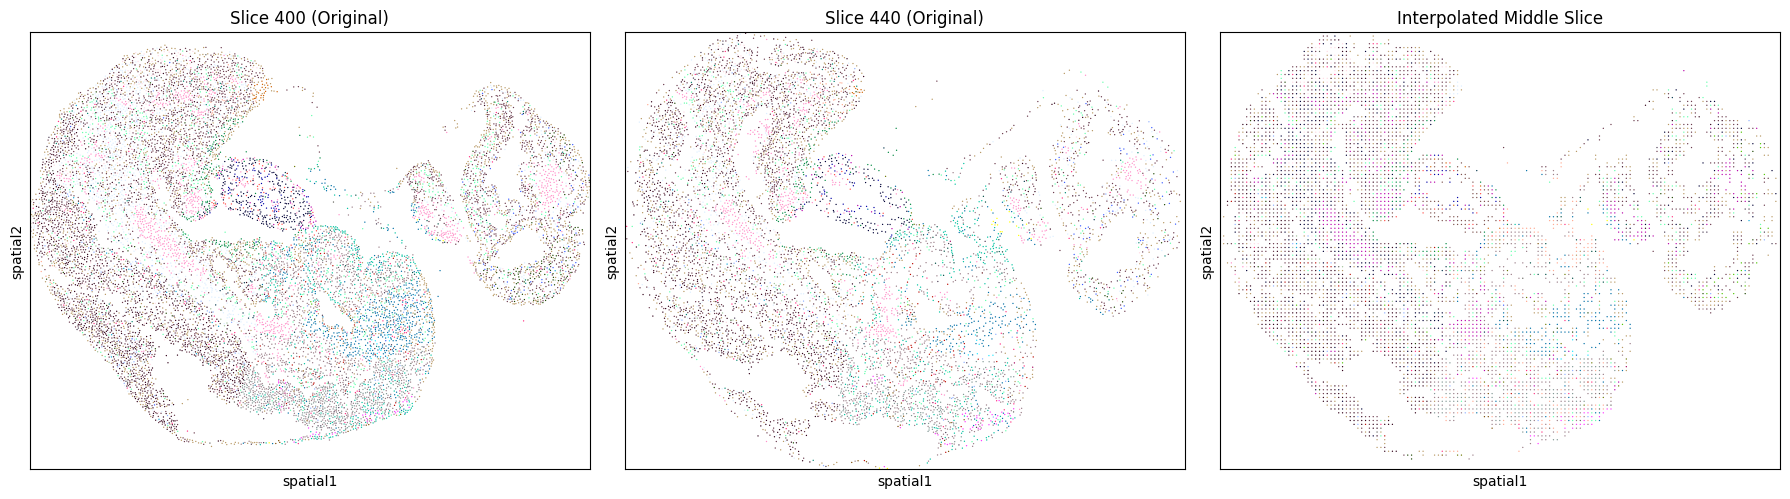

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

adatas = [adata_400, adata_440, middle]

# Common spatial range
all_xy = np.vstack([a.obsm["spatial"] for a in adatas])

xmin, xmax = all_xy[:, 0].min(), all_xy[:, 0].max()
ymin, ymax = all_xy[:, 1].min(), all_xy[:, 1].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sc.pl.spatial(
    adata_400,
    color="mapped_celltype",
    title="Slice 400 (Original)",
    ax=axes[0],
    show=False,
    legend_loc=None,
    spot_size=10
)

sc.pl.spatial(
    adata_440,
    color="mapped_celltype",
    title="Slice 440 (Original)",
    ax=axes[1],
    show=False,
    legend_loc=None,
    spot_size=10
)

sc.pl.spatial(
    middle,
    color="predicted_celltype",
    title="Interpolated Middle Slice",
    ax=axes[2],
    show=False,
    legend_loc=None,
    spot_size=10
)

for ax in axes:
    ax.set_xlim(xmin, xmax)

    ax.set_ylim(ymin, ymax)

    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### INR mode (with gene expression)

In [9]:
!pip install scikit-misc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 6.3 MB/s eta 0:00:00


In [10]:
### filter top 30 HVGs for simple illustration
sc.pp.highly_variable_genes(
    a,
    n_top_genes=30,
    flavor="seurat_v3"
)

In [11]:
hvg_genes = a.var_names[a.var["highly_variable"]]

In [12]:
adata_400 = adata_400[:, hvg_genes].copy()
adata_440 = adata_440[:, hvg_genes].copy()

In [13]:
middle = predict_middle_slice(
    adata_400, adata_440,
    mode="inr",
    label_key="mapped_celltype",
    work_dir="/content/UniST/unist_run",
    annotation_alpha=0.01,  # or "auto"
    embedder_epochs=50, # for simple illustration
    inr_epochs=100
)

INFO: Seed set to 8848
INFO:lightning.fabric.utilities.seed:Seed set to 8848


Using anisotropic KNN for 3D data: z_weight=2.0, z_threshold=None

Extracting neighbors from CSR matrix (21943 nodes)...

Processed 2194/21943 nodes (9%)

Processed 4388/21943 nodes (19%)

...

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/prediction_loop.py:257: predict returned None if it
was on purpose, ignore this warning...

Writing to 
/content/UniST/unist_run/GAE+FFN-3D-sparse/one_line/lightning_logs/version_1/reconstructed-custom-middle.h5ad ... 
It may take some time ...

Custom prediction saved under: /content/UniST/unist_run/GAE+FFN-3D-sparse/one_line/lightning_logs/version_1

/tmp/ipykernel_2930/1094880433.py:15: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_2930/1094880433.py:25: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_2930/1094880433.py:35: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


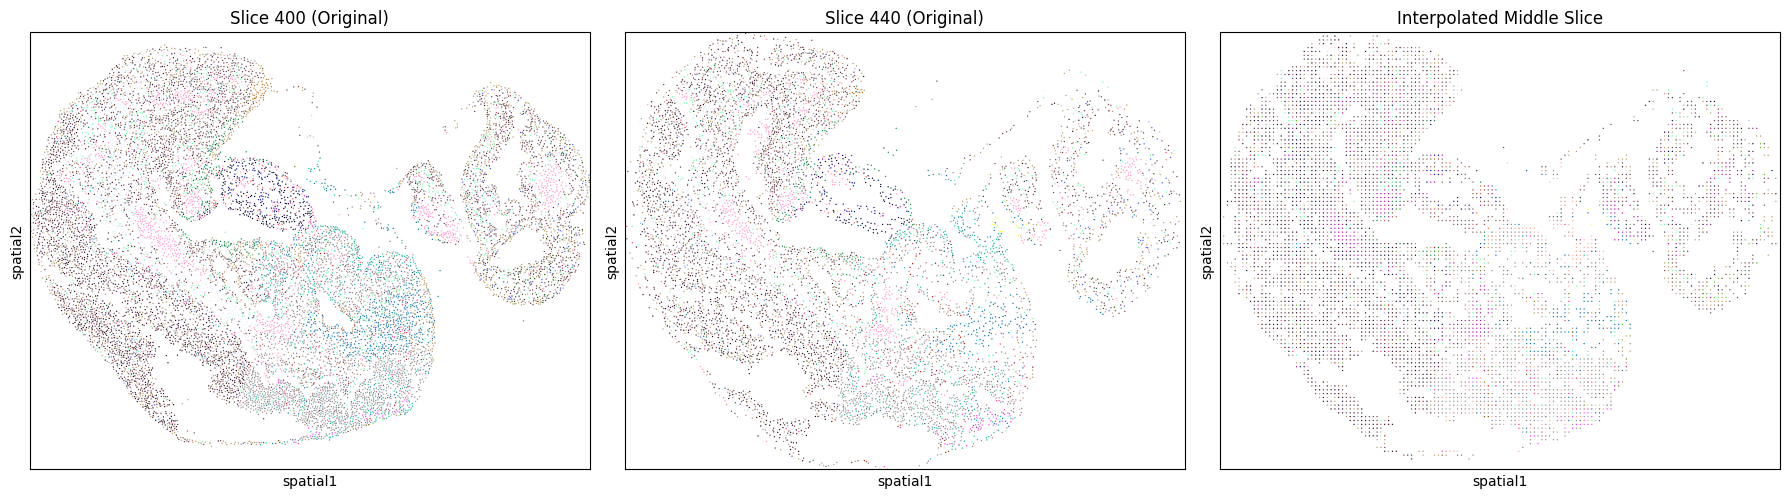

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

adatas = [adata_400, adata_440, middle]

# Common spatial range
all_xy = np.vstack([a.obsm["spatial"] for a in adatas])

xmin, xmax = all_xy[:, 0].min(), all_xy[:, 0].max()
ymin, ymax = all_xy[:, 1].min(), all_xy[:, 1].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sc.pl.spatial(
    adata_400,
    color="mapped_celltype",
    title="Slice 400 (Original)",
    ax=axes[0],
    show=False,
    legend_loc=None,
    spot_size=10
)

sc.pl.spatial(
    adata_440,
    color="mapped_celltype",
    title="Slice 440 (Original)",
    ax=axes[1],
    show=False,
    legend_loc=None,
    spot_size=10
)

sc.pl.spatial(
    middle,
    color="predicted_celltype",
    title="Interpolated Middle Slice",
    ax=axes[2],
    show=False,
    legend_loc=None,
    spot_size=10
)

for ax in axes:
    ax.set_xlim(xmin, xmax)

    ax.set_ylim(ymin, ymax)

    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2930/3759311683.py:6: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


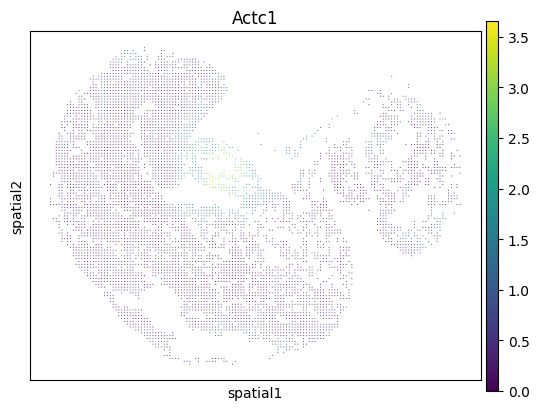

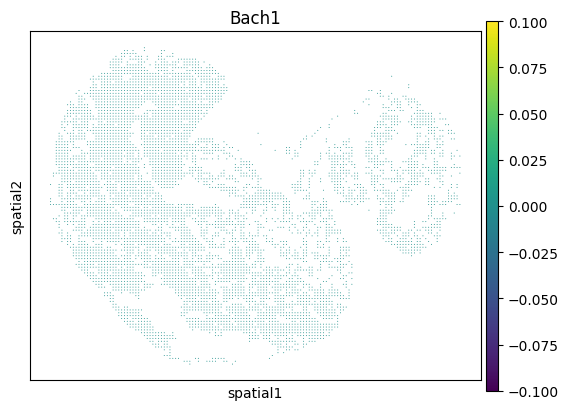

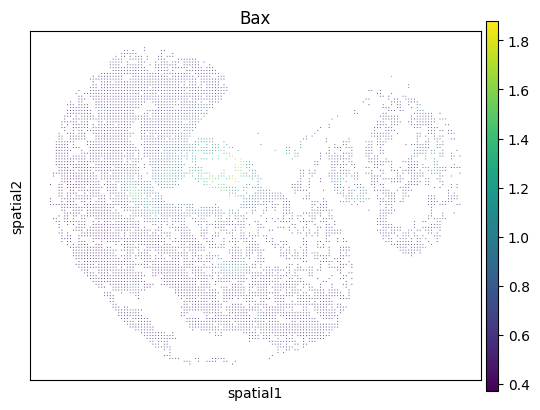

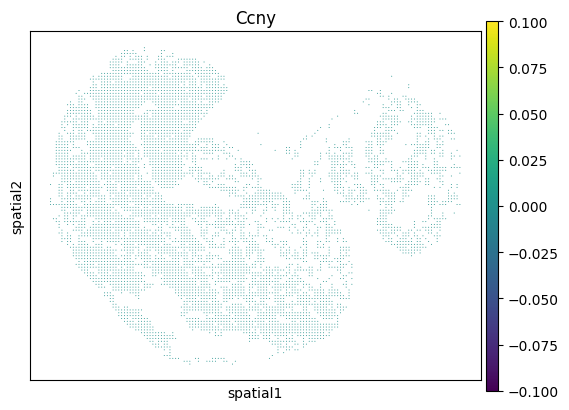

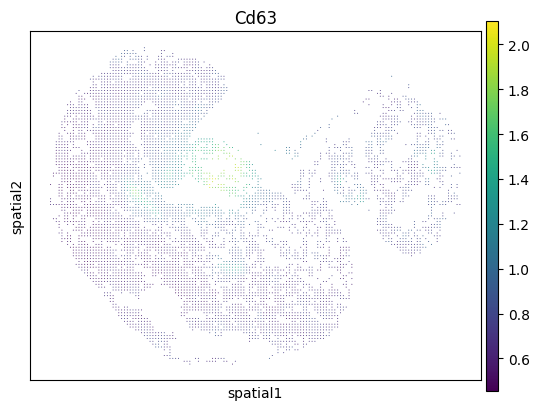

In [20]:
### visualize top 5 HVGs (limited by epochs = 50, larger number of epochs is better)

top_5_genes = hvg_genes[:5]

for i, gene in enumerate(top_5_genes):
    middle.obs[gene] = middle.obsm["reconstructed_raw"][:, i]

    sc.pl.spatial(
        middle,
        color=gene,
        title=gene,
        spot_size=10,
        cmap="viridis",
        legend_loc=None,
        show=False
    )

    plt.gca().invert_yaxis()
    plt.gca().set_aspect("equal")
    plt.show()